<a href="https://colab.research.google.com/github/lorenzkap/ML2026/blob/main/14_sequence_models_lstm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<!-- nav-header -->
[⬅ Previous](https://colab.research.google.com/github/lorenzkap/ML2026/blob/main/13_fairness_and_subgroups.ipynb) · [🗺️ Course index](https://colab.research.google.com/github/lorenzkap/ML2026/blob/main/00_START_HERE.ipynb) · **Notebook 14 of the course** · [Next: 15 — Capstone challenge ➡](https://colab.research.google.com/github/lorenzkap/ML2026/blob/main/15_capstone_challenge.ipynb)

# 🔁 Notebook 14 — Sequence models: an LSTM on the raw 4-hourly data

> Every model so far has been fed **one row per patient**. To get there we took a
> patient's whole ICU stay and collapsed it into `mean`, `min`, `max`, `last`. This notebook
> asks the obvious question: **is the order of events worth anything?**

Notebooks 05–09 and 13 all start from `sepsis_patients.csv` — the flattened table built in
Notebook 04. Flattening is not a crime; it is what makes the problem tractable, and the
`_delta` features in Notebook 04 already claw back a little of the trend. But a mean cannot
tell you *when* the lactate rose, and a random forest cannot give you a risk that updates at
the bedside every four hours. An LSTM can do both.

**What you'll learn**
- How to reshape a long clinical table into the **(patients × timesteps × features)** tensor a sequence model needs
- **Padding and masking** — the single most common silent bug in clinical deep learning
- How to build and train an **LSTM** in PyTorch, with early stopping on a validation split
- How to compare it *fairly* against a strong flattened-table baseline, with a **paired bootstrap**
- Why, on a cohort of this size, the honest answer is usually **"it ties"** — and what the LSTM is still worth

**⏱️ Time:** ≈40 min · **Prerequisites:** Notebooks 04 (feature engineering), 05 (models), 06 (evaluation), 08 (leakage).

> 🩺 **The task is deliberately harder than Notebook 05's.** We predict 90-day mortality from the
> **first 48 hours only**, not from the whole stay. That is the clinically useful version — a score
> you could act on — and it is why every AUC here is lower than the 0.77–0.78 you saw earlier.
> Do not compare across notebooks; compare the two models *on this page*, which see exactly the same data.

## ⚙️ Run me first

In [ ]:
# === ⚙️  Workshop setup — run this cell first ===============================
# Works in Google Colab and in local Jupyter. Installs anything missing, sets a
# clean plotting style, and gives you helpers to load the data.
# (This cell is identical in every notebook of the course.)
import importlib.util, subprocess, sys, os, random, warnings
warnings.filterwarnings("ignore")

# --- reproducibility: everyone in the room gets the same numbers ---------------
RANDOM_STATE = 42
os.environ["PYTHONHASHSEED"] = str(RANDOM_STATE)
random.seed(RANDOM_STATE)

# 📥 Where the workshop data comes from — already set up for you, nothing to do.
# The data downloads automatically the first time you need it. If you were given a
# different link, just paste it in place of the one below. These forms all work:
#   • a Google-Drive folder link      • a Drive / Dropbox / OneDrive file link
#   • a folder URL ending in "/"      • a link straight to a .zip
# Set it to "" if you would rather upload the CSVs by hand.
# (The data is not in the GitHub repo: it is real de-identified patient data covered
#  by a data use agreement and may not be redistributed openly.)
WORKSHOP_DATA_URL = os.environ.get(
    "WORKSHOP_DATA_URL",
    "https://drive.google.com/drive/folders/1y7CparhrqdlCAZq6xQlj8fZda394fniD")

def _ensure(pkgs):
    missing = [pip for mod, pip in pkgs.items() if importlib.util.find_spec(mod) is None]
    if missing:
        print("Installing:", *missing)
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", *missing])
_ensure({"numpy":"numpy","pandas":"pandas","sklearn":"scikit-learn",
         "matplotlib":"matplotlib","seaborn":"seaborn","shap":"shap","xgboost":"xgboost",
         "torch":"torch"})     # ← notebook 14 is the only one that needs PyTorch

import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
np.random.seed(RANDOM_STATE)          # seeds the legacy global np.random.* calls
RNG = np.random.default_rng(RANDOM_STATE)   # the modern generator — use this one
pd.set_option("display.max_columns", 120); pd.set_option("display.width", 160)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (9, 5); plt.rcParams["figure.dpi"] = 110

# Every model, split and resample in this course passes random_state=RANDOM_STATE, so
# your numbers should match your neighbour's exactly. (Different library *versions* can
# still shift the last decimal — that is normal and not a mistake on your part.)

# --- data loading: works locally AND remembers your upload across notebooks -----
_CACHE = {"dir": "unset"}   # memo so we only touch Google Drive once per session

def _in_colab():
    try:
        import google.colab  # noqa: F401
        return True
    except Exception:
        return False

def _drive_cache():
    """In Google Colab, mount Drive ONCE and return a persistent folder. A file you
    upload in one notebook is saved here, so every other notebook opens it automatically
    — no re-uploading. Returns None outside Colab, or if you decline to connect Drive."""
    if _CACHE["dir"] != "unset":
        return _CACHE["dir"]
    result = None
    if _in_colab():
        try:
            from google.colab import drive
            if not os.path.ismount("/content/drive"):
                drive.mount("/content/drive")
            result = "/content/drive/MyDrive/sepsis_workshop_data"
            os.makedirs(result, exist_ok=True)
        except Exception:
            result = None
    _CACHE["dir"] = result
    return result

def _find(name):
    """Look for the file on disk. Deliberately does NOT touch Google Drive, so the normal
    path never triggers an authorisation popup."""
    for p in [name, f"data/{name}", f"../data/{name}", f"workshop/data/{name}"]:
        if os.path.exists(p):
            return p
    return None

def _find_in_drive(name):
    """Only used as a fallback, because it mounts Drive (and that means a popup)."""
    cache = _drive_cache()
    if cache:
        p = os.path.join(cache, name)
        if os.path.exists(p):
            return p
    return None

def _direct_url(u):
    """Turn an ordinary Google-Drive / Dropbox / OneDrive *share* link into one that a
    plain HTTP client can actually download, so you can paste the link you were given."""
    import re
    m = (re.search(r"drive\.google\.com/file/d/([\w-]+)", u)
         or re.search(r"drive\.google\.com/(?:open|uc)\?(?:export=\w+&)?id=([\w-]+)", u))
    if m:
        return f"https://drive.google.com/uc?export=download&id={m.group(1)}"
    if "dropbox.com" in u:
        return u.split("?")[0] + "?dl=1"
    if "sharepoint.com" in u or "1drv.ms" in u:
        return u + ("&" if "?" in u else "?") + "download=1"
    return u

def _fetch(url, dest):
    import urllib.request, shutil as _sh
    req = urllib.request.Request(_direct_url(url), headers={"User-Agent": "Mozilla/5.0"})
    with urllib.request.urlopen(req, timeout=120) as r, open(dest, "wb") as f:
        _sh.copyfileobj(r, f)

_FOLDER = {"done": False}

def _gdrive_folder(name):
    """WORKSHOP_DATA_URL points at a Google-Drive *folder*: fetch it once with gdown
    (a folder cannot be downloaded with a plain HTTP request), then serve files from it."""
    dest = "_workshop_data"
    if not _FOLDER["done"]:
        _ensure({"gdown": "gdown"})
        import gdown
        print("⬇  fetching the workshop data from Google Drive (just once) …")
        gdown.download_folder(url=WORKSHOP_DATA_URL, output=dest, quiet=True, use_cookies=False)
        _FOLDER["done"] = True
    for root, _dirs, files in os.walk(dest):
        if name in files:
            return os.path.join(root, name)
    return None

def _try_download(name):
    """Fetch the data from WORKSHOP_DATA_URL, if one was configured."""
    u = (WORKSHOP_DATA_URL or "").strip()
    if not u:
        return None
    try:
        if "/drive/folders/" in u:
            return _gdrive_folder(name)
        if u.lower().split("?")[0].endswith(".zip"):
            import zipfile
            bundle = "_workshop_data.zip"
            if not os.path.exists(bundle):
                print("⬇  downloading the workshop data bundle …")
                _fetch(u, bundle)
            with zipfile.ZipFile(bundle) as z:      # flatten any folder inside the zip
                for member in z.namelist():
                    if os.path.basename(member) == name:
                        with z.open(member) as src, open(name, "wb") as dst:
                            dst.write(src.read())
                        return name
            print(f"  ({name} was not inside the bundle)")
            return None
        print(f"⬇  downloading {name} …")
        _fetch(u.rstrip("/") + "/" + name, name)
        return name
    except Exception as e:
        print(f"  (download failed: {e})")
        for leftover in (name, "_workshop_data.zip"):
            if os.path.exists(leftover) and os.path.getsize(leftover) == 0:
                os.remove(leftover)
        return None

def _cache_to_drive(name, data):
    cache = _drive_cache()
    if cache:
        dest = os.path.join(cache, name)
        data.to_csv(dest, index=False)
        print(f"  💾 saved to Google Drive ({dest}) — no need to fetch it again.")

def load_csv(name):
    """Load a data CSV: looks on disk, then downloads it from WORKSHOP_DATA_URL, then checks
    your Google-Drive cache, and only as a last resort asks you to upload it — in which case
    it saves a copy to Drive so you never have to upload it twice."""
    p = _find(name)                       # 1. already on disk?
    if p:
        print(f"✓ loaded {p}")
        return pd.read_csv(p)
    p = _try_download(name)               # 2. the built-in download link
    if p:
        print(f"✓ loaded {name}")
        return pd.read_csv(p)
    p = _find_in_drive(name)              # 3. a copy you saved on a previous run
    if p:
        print(f"✓ loaded {p}")
        return pd.read_csv(p)
    try:                                  # 4. last resort: upload it by hand
        from google.colab import files
        print(f"⤴  Upload {name} just once — I'll save it so the other notebooks open it automatically:")
        up = files.upload()
        fname = list(up.keys())[0]
        data = pd.read_csv(fname)
        _cache_to_drive(name, data)
        return data
    except Exception:
        raise FileNotFoundError(
            f"Could not find {name}. Either paste your download link into WORKSHOP_DATA_URL at "
            f"the top of this cell, or put the CSV next to this notebook / in a data/ folder."
        )

## 📂 Load the *sequential* data

Not `sepsis_patients.csv` this time — the real thing: one row per patient **per 4-hour block**.

In [ ]:
ts = load_csv("sepsis_timeseries.csv")

blocs = ts.groupby("icustayid").size()
print(f"{len(ts):,} rows × {ts.shape[1]} columns")
print(f"{ts['icustayid'].nunique():,} ICU stays — one row per patient per 4-hour block (`bloc`)")
print(f"blocs per stay: median {blocs.median():.1f}, "
      f"10th–90th percentile {blocs.quantile(.1):.0f}–{blocs.quantile(.9):.0f}, max {blocs.max()}")
print(f"90-day mortality (per stay): {ts.groupby('icustayid')['morta_90'].max().mean():.1%}\n")
print(ts[["icustayid", "bloc", "HR", "SysBP", "Arterial_lactate", "SOFA", "morta_90"]]
      .head(6).to_string(index=False))

✓ loaded data/sepsis_timeseries.csv
37,704 rows × 53 columns
1,696 ICU stays — one row per patient per 4-hour block (`bloc`)
blocs per stay: median 14.5, 10th–90th percentile 6–62, max 69
90-day mortality (per stay): 18.2%

 icustayid  bloc    HR  SysBP  Arterial_lactate  SOFA  morta_90
  30003226     1 83.40 141.75               2.0     1         0
  30003226     2 69.71 147.86               1.1     7         0
  30003226     3 66.25 169.50               0.6     6         0
  30003226     4 72.12 145.50               1.0     6         0
  30003226     5 75.25 134.00               0.8     4         0
  30003226     6 64.43 144.25               0.7     4         0


## 🔍 Step 1 — what does flattening actually throw away?

Take the simplest summary, the mean. Two patients can share a mean and have lived opposite
48 hours. Let's find such a pair in the real cohort rather than assert it.

In [ ]:
WINDOW = 12          # 12 blocs × 4 h = the first 48 hours of the stay

first48 = (ts.sort_values(["icustayid", "bloc"]).groupby("icustayid").head(WINDOW).copy())
first48["t_hours"] = first48.groupby("icustayid").cumcount() * 4
outcome = first48.groupby("icustayid")["morta_90"].max()

# Find two patients the *flattened* table would call nearly identical: same mean
# lactate over the window, opposite trend, opposite outcome. Nothing is invented —
# this is a search over the real cohort, and you can re-run it for any feature.
lac = first48.groupby("icustayid")["Arterial_lactate"].agg(["mean", "first", "last", "size"])
lac["trend"] = lac["last"] - lac["first"]
lac["died"] = outcome
full = lac[(lac["size"] >= 10) & lac["mean"].between(2.0, 4.5)]
rising_died = full[(full["trend"] > 1.5) & (full["died"] == 1)]
falling_lived = full[(full["trend"] < -1.5) & (full["died"] == 0)]

pairs = [(abs(falling_lived.loc[j, "mean"] - r["mean"]), i, j)
         for i, r in rising_died.iterrows()
         for j in [(falling_lived["mean"] - r["mean"]).abs().idxmin()]]
gap, id_died, id_lived = min(pairs)
print(f"Closest pair found: their mean lactate differs by {gap:.4f} mmol/L\n")
print(lac.loc[[id_died, id_lived], ["mean", "first", "last", "trend", "died"]]
      .round(2).to_string())

Closest pair found: their mean lactate differs by 0.0008 mmol/L

           mean  first  last  trend  died
icustayid                                
36383939   2.44    0.9  3.78   2.88     1
38889793   2.44    5.4  2.00  -3.40     0


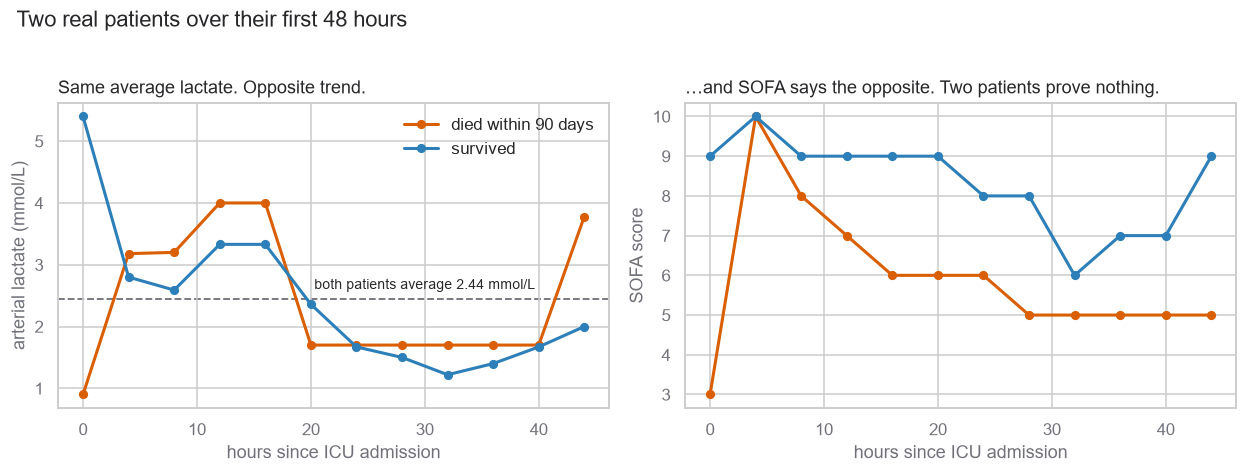

In [ ]:
# One colour per OUTCOME (not per patient) — identity is carried by colour + a
# direct label, never by colour alone. This pair is checked for colour-vision
# separation, so it survives print and colourblind readers.
C_DIED, C_LIVED = "#d95f02", "#2c7fb8"
INK, MUTED = "#27272a", "#71717a"

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.2), sharex=True)
panels = [("Arterial_lactate", "arterial lactate (mmol/L)"), ("SOFA", "SOFA score")]

for ax, (col, ylab) in zip(axes, panels):
    for sid, colour, name in [(id_died, C_DIED, "died within 90 days"),
                              (id_lived, C_LIVED, "survived")]:
        g = first48[first48["icustayid"] == sid]
        ax.plot(g["t_hours"], g[col], "-o", color=colour, lw=2, ms=5, label=name)
    ax.set_xlabel("hours since ICU admission", color=MUTED)
    ax.set_ylabel(ylab, color=MUTED)
    ax.tick_params(colors=MUTED)

shared_mean = lac.loc[id_died, "mean"]
axes[0].axhline(shared_mean, ls="--", lw=1.2, color=MUTED, zorder=0)
axes[0].text(30, shared_mean + 0.12, f"both patients average {shared_mean:.2f} mmol/L",
             color=INK, fontsize=9, ha="center", va="bottom")
axes[0].set_title("Same average lactate. Opposite trend.", color=INK, loc="left")
axes[1].set_title("…and SOFA says the opposite. Two patients prove nothing.",
                  color=INK, loc="left")
axes[0].legend(frameon=False, loc="upper right")

fig.suptitle("Two real patients over their first 48 hours", color=INK, y=1.02, x=0.02, ha="left")
plt.tight_layout(); plt.show()

### 📖 Read both panels — especially the right one

The left panel is the pitch for sequence models: identical mean lactate (2.44 mmol/L for both),
one patient climbing to 3.8 and dying, one falling from 5.4 and surviving. A feature set of
`mean`/`min`/`max` cannot separate them.

The right panel is the reason we do not stop there. On **SOFA**, the patient who died had the
*lower and falling* score, and the survivor stayed high. Two patients selected to make a point
prove exactly nothing — which is the same lesson as Notebook 13's bootstrap. So let's ask the
whole cohort instead.

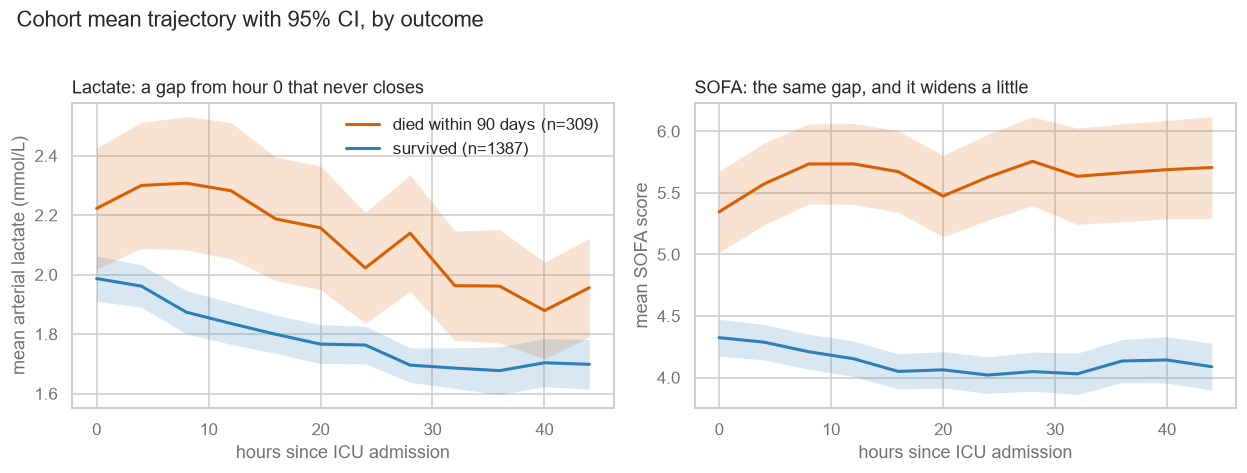

In [ ]:
# Is that pair a fluke, or does the whole cohort separate by trajectory?
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.2), sharex=True)

for ax, (col, ylab) in zip(axes, panels):
    for died, colour, name in [(1, C_DIED, "died within 90 days"), (0, C_LIVED, "survived")]:
        sub = first48[first48["icustayid"].map(outcome) == died]
        stat = sub.groupby("t_hours")[col].agg(["mean", "sem", "size"])
        stat = stat[stat["size"] >= 30]          # don't draw a mean from a handful of patients
        ax.plot(stat.index, stat["mean"], "-", color=colour, lw=2, label=f"{name} (n={sub['icustayid'].nunique()})")
        ax.fill_between(stat.index, stat["mean"] - 1.96 * stat["sem"],
                        stat["mean"] + 1.96 * stat["sem"], color=colour, alpha=0.18, lw=0)
    ax.set_xlabel("hours since ICU admission", color=MUTED)
    ax.set_ylabel(f"mean {ylab}", color=MUTED)
    ax.tick_params(colors=MUTED)

axes[0].set_title("Lactate: a gap from hour 0 that never closes", color=INK, loc="left")
axes[1].set_title("SOFA: the same gap, and it widens a little", color=INK, loc="left")
axes[0].legend(frameon=False)
fig.suptitle("Cohort mean trajectory with 95% CI, by outcome", color=INK, y=1.02, x=0.02, ha="left")
plt.tight_layout(); plt.show()

☝️ Now it holds up: across all 1,696 stays the two outcome groups are separated **from hour 0**
on lactate and on SOFA, and the SOFA gap widens (1.0 → 1.6 points) over the two days.

Note what this figure does *not* prove: that the **shape** of the curve adds anything beyond its
level. Both groups are essentially flat. If mortality is written in the *level* of lactate rather
than its trajectory, then `mean` was a perfectly good feature all along, and a sequence model has
nothing left to find. Keep that hypothesis alive — the results at the end will speak to it.

## 🧱 Step 2 — from a long table to a 3-D tensor

A sequence model does not eat a DataFrame. It eats a block of numbers shaped

```
(patients, timesteps, features)      here: (1696, 12, 20)
```

Three decisions have to be made explicit, because each one is a place people silently lose data:

| Decision | Ours | Why |
|---|---|---|
| **How long a window?** | first **12 blocks = 48 h** | an early-warning score has to work early; using the whole stay lets the model see the patient dying |
| **What about short stays?** | keep them, **pad** to 12 and **mask** | dropping them would quietly select for survivors, who stay longer |
| **What about implausible values?** | clip to physiological limits, then carry the last value forward *within* the stay | Notebook 02's lesson — this file contains a 3913 °F and a heart rate of 0 |

In [ ]:
DYNAMIC = ["HR", "SysBP", "MeanBP", "RR", "SpO2", "Temp_C", "GCS", "Arterial_lactate",
           "Creatinine", "BUN", "WBC_count", "Hb", "SOFA", "Shock_Index",
           "mechvent", "max_dose_vaso"]
STATIC  = ["age", "gender", "elixhauser", "re_admission"]
FEATURES = DYNAMIC + STATIC

# Physiological plausibility limits — these are clinical facts, not learned from the
# data, so applying them before the split leaks nothing. (Notebook 02's lesson: the
# file contains a 3913 °F and a heart rate of 0.)
LIMITS = {"HR": (20, 300), "SysBP": (40, 300), "MeanBP": (20, 220), "RR": (3, 80),
          "SpO2": (30, 100), "Temp_C": (25, 45), "GCS": (3, 15),
          "Arterial_lactate": (0.1, 30), "Creatinine": (0.1, 25), "BUN": (1, 200),
          "WBC_count": (0.1, 200), "Hb": (2, 25), "Shock_Index": (0.1, 3)}

seq = first48.copy()
for c, (lo, hi) in LIMITS.items():
    seq[c] = seq[c].where(seq[c].between(lo, hi))
seq[DYNAMIC] = seq.groupby("icustayid", group_keys=False)[DYNAMIC].apply(lambda g: g.ffill().bfill())

# ── the 3-D tensor: (patients, timesteps, features) ──────────────────────────
ids  = seq["icustayid"].drop_duplicates().to_numpy()
row  = seq["icustayid"].map({s: i for i, s in enumerate(ids)}).to_numpy()
tcol = seq.groupby("icustayid").cumcount().to_numpy()

X = np.full((len(ids), WINDOW, len(FEATURES)), np.nan, dtype="float32")
X[row, tcol] = seq[FEATURES].to_numpy(dtype="float32")
lengths = np.bincount(row, minlength=len(ids))
mask    = np.arange(WINDOW)[None, :] < lengths[:, None]
y       = outcome.reindex(ids).to_numpy().astype("float32")

print(f"X       {X.shape}   ← {X.shape[0]:,} patients × {X.shape[1]} timesteps × {X.shape[2]} features")
print(f"lengths {lengths.shape}  how many 4-h blocks each patient actually has")
print(f"y       {y.shape}  90-day mortality, one label per patient\n")
print(f"patients with the full {WINDOW} blocks: {(lengths == WINDOW).mean():.1%}")
print(f"patients with fewer than 4 blocks:    {(lengths < 4).mean():.1%}")
print(f"padded (non-existent) timesteps:      {(~mask).mean():.1%} of the tensor — these must be MASKED, never learned from")

X       (1696, 12, 20)   ← 1,696 patients × 12 timesteps × 20 features
lengths (1696,)  how many 4-h blocks each patient actually has
y       (1696,)  90-day mortality, one label per patient

patients with the full 12 blocks: 63.4%
patients with fewer than 4 blocks:    1.5%
padded (non-existent) timesteps:      13.7% of the tensor — these must be MASKED, never learned from


> ⚠️ **13.7% of the tensor is padding.** Those timesteps do not exist. If you let the model
> average over them, or take `x[:, -1]` as "the last measurement", you have just fed it a
> fabricated patient. The `lengths` array is what stops that — and `pack_padded_sequence` below
> is what enforces it.

### The split, and where the scaler is allowed to look

Same discipline as Notebook 08: split **by patient**, then compute the mean and standard deviation
**on the training patients only** and apply them everywhere. A neural net needs scaled inputs, which
makes it far easier to leak than a forest — the scaler is a model, and it must not see the test set.

We also carve a **validation** split out of the training data. The LSTM needs it to decide when to
stop; the forest does not. That is a real cost of neural nets on small data, and we account for it
below by fitting the forest both ways.

In [ ]:
from sklearn.model_selection import train_test_split

idx = np.arange(len(ids))
idx_fit, idx_test = train_test_split(idx, test_size=0.3, stratify=y, random_state=RANDOM_STATE)
idx_train, idx_val = train_test_split(idx_fit, test_size=0.2, stratify=y[idx_fit], random_state=RANDOM_STATE)

# Standardise on the TRAINING patients only, and only over timesteps that exist.
flat = X[idx_train][mask[idx_train]]
mu, sd = np.nanmean(flat, axis=0), np.nanstd(flat, axis=0)
sd[sd == 0] = 1.0

Xz = np.clip((X - mu) / sd, -5, 5)      # z-score, then clip the wildest 5-sigma tails
Xz = np.nan_to_num(Xz, nan=0.0)         # a feature never recorded for a stay -> the train mean
Xz[~mask] = 0.0                         # padding is zero AND masked, so it cannot contribute

for name, sel in [("train", idx_train), ("val", idx_val), ("test", idx_test)]:
    print(f"{name:6s} {len(sel):5,d} patients   {y[sel].mean():5.1%} mortality")
print(f"\nfeature means on train (should be ~0): {Xz[idx_train][mask[idx_train]].mean():+.4f}")
print(f"feature sd    on train (should be ~1): {Xz[idx_train][mask[idx_train]].std():.4f}")

train    949 patients   18.2% mortality
val      238 patients   18.1% mortality
test     509 patients   18.3% mortality

feature means on train (should be ~0): -0.0024
feature sd    on train (should be ~1): 0.9456


## 🌲 Step 3 — the opponent: a forest on the flattened window

To make this a fair fight, the baseline gets the **same 48 hours**, flattened exactly the way
Notebook 04 does it: `mean`, `min`, `max`, `last` and `last − first` for each channel, plus the
static variables. That last term matters — it means the baseline is *not* blind to trend. Beating a
strawman that only gets the mean would prove nothing.

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, average_precision_score

def window_features(Xr, msk):
    """Flatten each patient's window the Notebook-04 way: mean/min/max/last/delta
    per channel. This is the honest opponent — it already knows about trends."""
    A = np.where(msk[:, :, None], Xr, np.nan)[:, :, :len(DYNAMIC)]
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")                  # all-NaN channels are expected
        agg = [np.nanmean(A, 1), np.nanmin(A, 1), np.nanmax(A, 1)]
    last = Xr[np.arange(len(Xr)), msk.sum(1) - 1, :len(DYNAMIC)]
    first = Xr[:, 0, :len(DYNAMIC)]
    return np.hstack(agg + [last, last - first, Xr[:, 0, len(DYNAMIC):]])

Xflat = window_features(X, mask)      # raw units — a forest does not need scaling
print(f"flattened table: {Xflat.shape[1]} features per patient "
      f"({len(DYNAMIC)} channels × 5 summaries + {len(STATIC)} static)\n")

def new_forest():
    return Pipeline([("impute", SimpleImputer(strategy="median")),
                     ("rf", RandomForestClassifier(n_estimators=400, min_samples_leaf=3,
                                                   class_weight="balanced",
                                                   random_state=RANDOM_STATE, n_jobs=-1))])

rf = new_forest().fit(Xflat[idx_train], y[idx_train])
p_rf = rf.predict_proba(Xflat[idx_test])[:, 1]

# and the same forest allowed the validation patients too, since it needs no early stopping
rf_full = new_forest().fit(Xflat[idx_fit], y[idx_fit])
p_rf_full = rf_full.predict_proba(Xflat[idx_test])[:, 1]

print(f"Random forest on the flattened window (train only)      test AUC {roc_auc_score(y[idx_test], p_rf):.3f}")
print(f"Random forest, also given the validation patients        test AUC {roc_auc_score(y[idx_test], p_rf_full):.3f}")

flattened table: 84 features per patient (16 channels × 5 summaries + 4 static)

Random forest on the flattened window (train only)      test AUC 0.728
Random forest, also given the validation patients        test AUC 0.732


## 🔁 Step 4 — the LSTM

An LSTM walks along the sequence one timestep at a time, carrying a **hidden state** — a running
summary of everything it has seen. At each step it decides, through learned gates, what to keep,
what to forget, and what to add. After the last real timestep, that hidden state is the patient's
history compressed into 32 numbers, and a single linear layer turns it into a risk.

Two lines carry all the correctness:

- `pack_padded_sequence(x, lengths, ...)` — **this is the masking.** The LSTM never sees a padded
  step, and the hidden state we read out is the one at each patient's *own* final timestep.
- `pos_weight` in the loss — 18% of patients die, so without it the model can score well by
  predicting "survives" for everyone.

Watch the parameter count against the number of patients when it prints.

In [ ]:
import torch
import torch.nn as nn

torch.manual_seed(RANDOM_STATE)
torch.use_deterministic_algorithms(True)

class SeqNet(nn.Module):
    """One LSTM layer, then a linear head on the last *real* timestep."""
    def __init__(self, n_feat, hidden=32, dropout=0.3):
        super().__init__()
        self.lstm = nn.LSTM(n_feat, hidden, batch_first=True)
        self.drop = nn.Dropout(dropout)
        self.head = nn.Linear(hidden, 1)

    def forward(self, x, lengths):
        # pack_padded_sequence is the masking: the LSTM never sees a padded step,
        # and h is the hidden state at each patient's OWN last timestep.
        packed = nn.utils.rnn.pack_padded_sequence(x, lengths, batch_first=True, enforce_sorted=False)
        _, (h, _) = self.lstm(packed)
        return self.head(self.drop(h[-1])).squeeze(1)

def tensors(sel):
    return (torch.tensor(Xz[sel]), torch.tensor(lengths[sel], dtype=torch.int64),
            torch.tensor(y[sel]))

Xtr, Ltr, ytr = tensors(idx_train)
Xva, Lva, yva = tensors(idx_val)
Xte, Lte, yte = tensors(idx_test)

model = SeqNet(len(FEATURES))
n_par = sum(p.numel() for p in model.parameters())
pos_weight = torch.tensor((y[idx_train] == 0).sum() / (y[idx_train] == 1).sum())
lossfn = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
opt = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

print(f"{n_par:,} trainable parameters for {len(idx_train):,} training patients "
      f"({n_par/len(idx_train):.0f} parameters per patient — hold that thought)\n")

EPOCHS, BATCH, PATIENCE = 60, 64, 12
rng = np.random.default_rng(RANDOM_STATE)
history, best = [], {"auc": -1, "epoch": -1, "state": None}

for epoch in range(1, EPOCHS + 1):
    model.train()
    order, tot = rng.permutation(len(idx_train)), 0.0
    for i in range(0, len(order), BATCH):
        b = order[i:i + BATCH]
        opt.zero_grad()
        loss = lossfn(model(Xtr[b], Ltr[b]), ytr[b])
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        opt.step()
        tot += float(loss) * len(b)
    model.eval()
    with torch.no_grad():
        val_logit = model(Xva, Lva)
        val_loss = float(lossfn(val_logit, yva))
        val_auc = roc_auc_score(y[idx_val], torch.sigmoid(val_logit).numpy())
    history.append({"epoch": epoch, "train_loss": tot / len(order), "val_loss": val_loss, "val_auc": val_auc})
    if val_auc > best["auc"]:
        best = {"auc": val_auc, "epoch": epoch,
                "state": {k: v.clone() for k, v in model.state_dict().items()}}
    if epoch % 10 == 0 or epoch == 1:
        print(f"epoch {epoch:3d}  train loss {tot/len(order):.4f}  val loss {val_loss:.4f}  val AUC {val_auc:.3f}")
    if epoch - best["epoch"] >= PATIENCE:
        print(f"epoch {epoch:3d}  early stop — no val improvement for {PATIENCE} epochs")
        break

model.load_state_dict(best["state"])       # roll back to the best validation epoch
model.eval()
with torch.no_grad():
    p_lstm = torch.sigmoid(model(Xte, Lte)).numpy()
hist = pd.DataFrame(history)
print(f"\nbest epoch {best['epoch']} (val AUC {best['auc']:.3f})   →   test AUC {roc_auc_score(y[idx_test], p_lstm):.3f}")

6,945 trainable parameters for 949 training patients (7 parameters per patient — hold that thought)

epoch   1  train loss 1.1216  val loss 1.0830  val AUC 0.790
epoch  10  train loss 0.8131  val loss 0.9015  val AUC 0.806
epoch  19  early stop — no val improvement for 12 epochs

best epoch 7 (val AUC 0.814)   →   test AUC 0.735


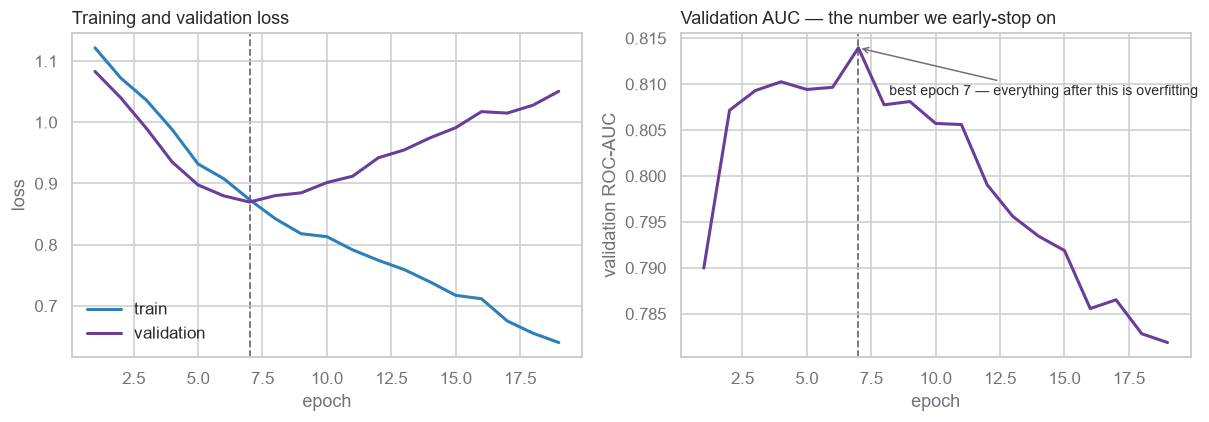

In [ ]:
C_TRAIN, C_VAL = "#2c7fb8", "#6a3d9a"

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4))
axes[0].plot(hist["epoch"], hist["train_loss"], color=C_TRAIN, lw=2, label="train")
axes[0].plot(hist["epoch"], hist["val_loss"], color=C_VAL, lw=2, label="validation")
axes[0].set_ylabel("loss", color=MUTED); axes[0].legend(frameon=False)
axes[0].set_title("Training and validation loss", color=INK, loc="left")

axes[1].plot(hist["epoch"], hist["val_auc"], color=C_VAL, lw=2)
axes[1].set_ylabel("validation ROC-AUC", color=MUTED)
axes[1].set_title("Validation AUC — the number we early-stop on", color=INK, loc="left")

for ax in axes:
    ax.set_xlabel("epoch", color=MUTED); ax.tick_params(colors=MUTED)
    ax.axvline(best["epoch"], ls="--", lw=1.2, color=MUTED, zorder=0)
axes[1].annotate(f"best epoch {best['epoch']} — everything after this is overfitting",
                 xy=(best["epoch"], best["auc"]),
                 xytext=(best["epoch"] + 1.2, best["auc"] - 0.004), color=INK, fontsize=9,
                 va="top", arrowprops=dict(arrowstyle="->", color=MUTED, lw=1))
plt.tight_layout(); plt.show()

### 📖 Read the curves

Training loss keeps falling. Validation loss bottoms out around **epoch 7** and then climbs for the
rest of the run, and validation AUC peaks at **0.814** before sliding to 0.782. That is textbook
overfitting, and it is exactly what **6,945 parameters and 949 patients** — about 7 parameters per
patient — should do.

Early stopping is not a nicety here; it is the only thing standing between you and a model that has
memorised the training ward. Note also that we early-stop on the *validation* AUC and report the
*test* AUC: choosing the epoch is model selection, and selecting on your test set is Notebook 08's
sin in a new costume.

## ⚖️ Step 5 — the honest comparison

Two models, same patients, same 48 hours. We report ROC-AUC **and** average precision (the
precision-recall summary, which is the more informative one when only 18% of patients have the
event), each with a bootstrap CI — and then the number that actually answers the question: the
**paired** difference, where both models are scored on the *same* resampled patients every time.

In [ ]:
yt = y[idx_test]
N_BOOT = 1000
brng = np.random.default_rng(RANDOM_STATE)
boot_idx = [b for b in (brng.integers(0, len(yt), len(yt)) for _ in range(N_BOOT))
            if len(np.unique(yt[b])) > 1]

def ci(pred, metric):
    v = [metric(yt[b], pred[b]) for b in boot_idx]
    return np.percentile(v, 2.5), np.percentile(v, 97.5)

rows = []
for name, pred in [("forest on flattened window", p_rf), ("LSTM on the raw sequence", p_lstm)]:
    auc_lo, auc_hi = ci(pred, roc_auc_score)
    ap_lo, ap_hi = ci(pred, average_precision_score)
    rows.append({"model": name,
                 "ROC-AUC": f"{roc_auc_score(yt, pred):.3f}", "AUC 95% CI": f"{auc_lo:.3f}–{auc_hi:.3f}",
                 "avg precision": f"{average_precision_score(yt, pred):.3f}", "AP 95% CI": f"{ap_lo:.3f}–{ap_hi:.3f}"})
print(pd.DataFrame(rows).set_index("model").to_string())

# The paired difference is the number that actually answers "is the LSTM better?" —
# the two models are scored on the SAME resampled patients every time.
d = [roc_auc_score(yt[b], p_lstm[b]) - roc_auc_score(yt[b], p_rf[b]) for b in boot_idx]
lo, hi = np.percentile(d, [2.5, 97.5])
print(f"\nΔ ROC-AUC (LSTM − forest): {roc_auc_score(yt, p_lstm) - roc_auc_score(yt, p_rf):+.3f}"
      f"   95% CI {lo:+.3f} – {hi:+.3f}")
print(f"bootstrap resamples in which the LSTM won: {np.mean(np.array(d) > 0):.1%}")

                           ROC-AUC   AUC 95% CI avg precision    AP 95% CI
model                                                                     
forest on flattened window   0.728  0.671–0.788         0.403  0.320–0.509
LSTM on the raw sequence     0.735  0.682–0.783         0.349  0.279–0.447

Δ ROC-AUC (LSTM − forest): +0.007   95% CI -0.031 – +0.044
bootstrap resamples in which the LSTM won: 66.0%


### 📖 The verdict: a tie, and one metric where the forest wins

- **ROC-AUC**: LSTM 0.735, forest 0.728. The difference is **+0.007 with a 95% CI of −0.031 to
  +0.044** — an interval comfortably straddling zero. The LSTM came out ahead in 66% of bootstrap
  resamples, which sounds like something and is not: a coin that lands heads 66 times in 100 is not
  evidence of a better model, and the CI is the honest summary.
- **Average precision**: forest **0.403**, LSTM **0.349** — the forest is *ahead* on the metric that
  matters most for a rare outcome, though those CIs overlap too.

So: **no evidence that reading the sequence beats flattening it here.** That is a real result, not a
failed experiment, and it is the most common result in clinical ML papers that bother to include a
strong baseline. The reasons are not mysterious:

1. **n = 1,696.** Sequence models are built to exploit large, repetitive data. Deep learning's wins
   in medicine come at 10⁴–10⁶ patients.
2. **The signal is in the level, not the shape** — which Step 1's cohort figure already hinted at.
   `mean` and `last` capture most of it, and Notebook 04's `delta` captures much of the rest.
3. **12 timesteps is a short sequence.** There is not much order for an LSTM to exploit.

> 🩺 **What to write in the paper.** Not "we applied a deep learning model". Write: *"An LSTM on the
> raw 4-hourly sequences did not outperform a random forest on aggregated features (ΔAUC +0.007,
> 95% CI −0.031 to +0.044)."* A negative result with a CI is worth more than a positive one without.

## ⏱️ Step 6 — what the LSTM gives you that the table cannot

If the headline number ties, why would you ever ship the harder model? Because a flattened-table
model needs the **whole window to exist** before it can say anything. It is a 48-hour-late answer.

An LSTM has a hidden state after *every* block, so you can ask it at hour 4, hour 8, hour 12 — the
same model, no retraining, no separate "4-hour model". That is a different clinical product: not a
score, a **monitor**.

Mean risk gap (died − survived) after 4 h: +0.040   after 48 h: +0.158
AUC using only the first 4 hours:  0.688
AUC using the full 48-hour window: 0.735


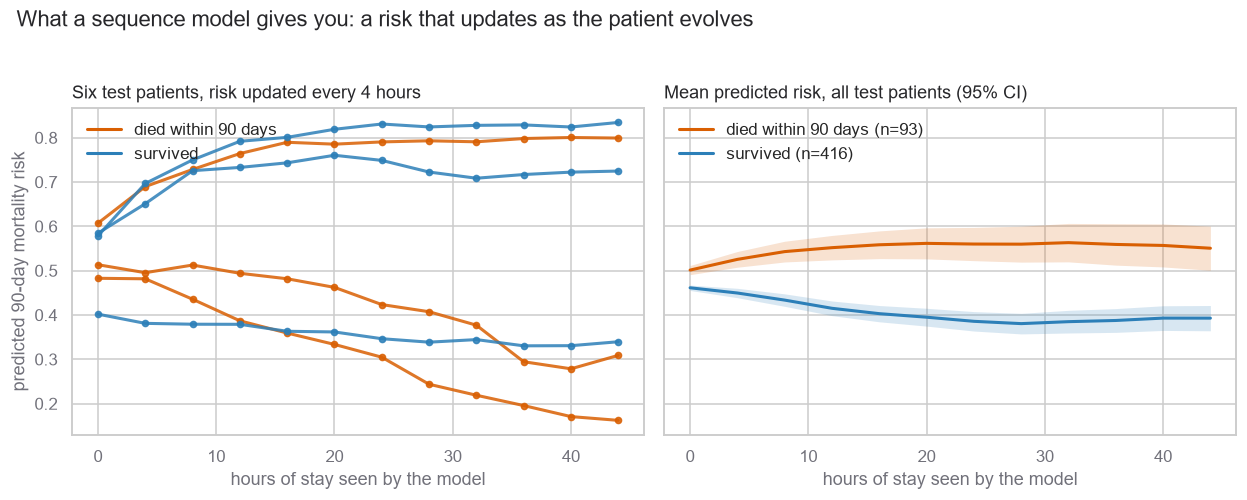

In [ ]:
def risk_over_time(sel):
    """Feed the model longer and longer prefixes of the stay: hours 0–4, 0–8, 0–12 …
    A flattened-table model cannot do this — it needs the whole window to exist first."""
    out = np.full((len(sel), WINDOW), np.nan)
    with torch.no_grad():
        for t in range(1, WINDOW + 1):
            ok = lengths[sel] >= t
            if not ok.any():
                continue
            xb = torch.tensor(Xz[sel][ok][:, :t])
            lb = torch.full((int(ok.sum()),), t, dtype=torch.int64)
            out[ok, t - 1] = torch.sigmoid(model(xb, lb)).numpy()
    return out

traj = risk_over_time(idx_test)
hours = np.arange(WINDOW) * 4

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.4), sharey=True)

# ── left: six individual test patients ───────────────────────────────────────
long_stay = np.where(lengths[idx_test] == WINDOW)[0]
picks = np.concatenate([long_stay[y[idx_test][long_stay] == 1][:3],
                        long_stay[y[idx_test][long_stay] == 0][:3]])
for k in picks:
    died = y[idx_test][k] == 1
    axes[0].plot(hours, traj[k], "-o", lw=2, ms=4,
                 color=C_DIED if died else C_LIVED, alpha=0.85)
axes[0].plot([], [], color=C_DIED, lw=2, label="died within 90 days")
axes[0].plot([], [], color=C_LIVED, lw=2, label="survived")
axes[0].set_title("Six test patients, risk updated every 4 hours", color=INK, loc="left")
axes[0].set_ylabel("predicted 90-day mortality risk", color=MUTED)
axes[0].legend(frameon=False, loc="upper left")

# ── right: the whole test set, so nothing is cherry-picked ───────────────────
for died, colour, name in [(1, C_DIED, "died within 90 days"), (0, C_LIVED, "survived")]:
    grp = traj[y[idx_test] == died]
    m = np.nanmean(grp, axis=0)
    se = np.nanstd(grp, axis=0) / np.sqrt(np.sum(~np.isnan(grp), axis=0))
    axes[1].plot(hours, m, color=colour, lw=2, label=f"{name} (n={len(grp)})")
    axes[1].fill_between(hours, m - 1.96 * se, m + 1.96 * se, color=colour, alpha=0.18, lw=0)
axes[1].set_title("Mean predicted risk, all test patients (95% CI)", color=INK, loc="left")
axes[1].legend(frameon=False, loc="upper left")

for ax in axes:
    ax.set_xlabel("hours of stay seen by the model", color=MUTED); ax.tick_params(colors=MUTED)
fig.suptitle("What a sequence model gives you: a risk that updates as the patient evolves",
             color=INK, y=1.03, x=0.02, ha="left")
plt.tight_layout(); plt.show()

sep = np.nanmean(traj[y[idx_test] == 1], 0) - np.nanmean(traj[y[idx_test] == 0], 0)
print(f"Mean risk gap (died − survived) after 4 h: {sep[0]:+.3f}   after 48 h: {sep[-1]:+.3f}")
early = ~np.isnan(traj[:, 0])
print(f"AUC using only the first 4 hours:  {roc_auc_score(y[idx_test][early], traj[early, 0]):.3f}")
print(f"AUC using the full 48-hour window: {roc_auc_score(y[idx_test], p_lstm):.3f}")

### 📖 Read it

The left panel is honest about the messiness: of six real patients, two who died have risk
trajectories that *fall* over the two days, and one survivor sits at the top of the chart
throughout. Individual trajectories are noisy, and you should distrust anyone who shows you six
hand-picked lines and no cohort plot.

The right panel is the cohort version, and it is the real finding: the two groups start almost
together (mean risk gap **+0.040** at hour 4) and separate steadily as the model watches
(**+0.158** by hour 48). The model genuinely learns from the unfolding stay rather than fixing an
opinion at admission.

And the practical number: **AUC 0.688 using only the first 4 hours**, against 0.735 with the full
48. Two-thirds of the discriminative power is available after a *single* block — which is the
argument for deploying an early score at all, and the argument for not waiting two days to produce
one.

## 🧭 When is a sequence model actually the right call?

**Reach for one when:**
- you have **many thousands** of patients, not one thousand;
- the **timing and order** of events plausibly carry the signal (ventilator weaning, drug response, sepsis onset);
- the sampling is **irregular** and you want the model to handle it, rather than binning into blocks first;
- you need a **continuously updating** risk, as in Step 6 — this can justify the model on its own, even at equal AUC;
- you want to avoid hand-designing features for **dozens of channels**, where `mean/min/max/last` is a lot of guesswork.

**Prefer the flattened table when:**
- the cohort is small (**this one**);
- you need a model a clinician can interrogate — Notebook 07's SHAP story is far harder on a hidden state;
- the outcome is plausibly a function of severity *level* rather than trajectory;
- you have to justify every parameter to a regulator.

**Things to try before an LSTM**, in ascending order of effort — each is often worth more than the
architecture change: add slope/variability/time-in-range features to the flattened table; use the
last value *and* the delta over several windows; try gradient boosting on those features; then a
**GRU** (fewer parameters than an LSTM, often equal); then a **temporal CNN** (fast, and strong on
short sequences); and only then a transformer, which is hungrier for data than anything above.

## ✏️ Your turn

1. **Shorten the window.** Set `WINDOW = 6` (24 hours) and re-run. How much AUC do you lose, and
   does the gap between the forest and the LSTM change? (Earlier prediction is more useful *and*
   harder — that trade-off is the whole design of an early-warning score.)
2. **Break the masking on purpose.** Replace `pack_padded_sequence` with a plain
   `self.lstm(x)` and read out `out[:, -1]` — the last *padded* step. The validation AUC will move.
   Explain in one sentence why, and why this bug is so easy to miss.
3. **Try a GRU.** Swap `nn.LSTM` for `nn.GRU` (the call signature is nearly identical, but it
   returns only `h`, not `(h, c)`). It has roughly 25% fewer parameters — does it do better on a
   cohort this small?
4. **Give the forest the trend features the LSTM might be finding.** Add the slope of a least-squares
   fit per channel to `window_features`. If the forest picks up the LSTM's +0.007, what does that
   tell you about what the LSTM had learned?
5. **Repeat the whole comparison over 5 different splits** (as Notebook 13's Step 7 does for
   fairness). Does the LSTM stay ahead, and by how much does the ΔAUC bounce around?

## 🔑 Take-home

> **A sequence model is a claim that the order matters. Test the claim against a strong flattened
> baseline, with a paired bootstrap — and be prepared for a tie.**

Three things worth carrying out of this notebook:

- **The tensor and the mask are the hard part.** Most clinical deep-learning bugs live in the shape
  of the data, not in the architecture. If 13.7% of your tensor is padding, 13.7% of your model's
  input is fiction unless you mask it.
- **Compare paired, and report the interval.** `+0.007 (−0.031 to +0.044)` is a complete answer.
  "The LSTM achieved 0.735" is not.
- **A model can be worth shipping for what it *does*, not what it scores.** The risk-every-4-hours
  monitor in Step 6 is a different clinical product from a 48-hour-late score, at the same AUC.

## 📚 Further reading
- Hochreiter & Schmidhuber, *Long short-term memory*, **Neural Computation** 1997 — the original.
- Lipton et al., *Learning to diagnose with LSTM recurrent neural networks*, **ICLR** 2016 — the clinical-sequence starting point.
- Harutyunyan et al., *Multitask learning and benchmarking with clinical time series data*, **Scientific Data** 2019 — the MIMIC-III benchmark, and a realistic picture of how much deep learning buys.
- Rajkomar et al., *Scalable and accurate deep learning with electronic health records*, **npj Digital Medicine** 2018 — what these models do when you have 200,000 patients instead of 1,700.
- Christodoulou et al., *A systematic review shows no performance benefit of machine learning over logistic regression for clinical prediction models*, **J Clin Epidemiol** 2019 — read this before believing any single comparison, including ours.

<!-- nav-footer -->
---

### ➡️ Next up — Notebook 15: Capstone challenge

That is the last thing we teach you. What remains is for you to use it: the capstone hands you
a held-out set and asks you to beat the baseline — with every habit from the last 14 notebooks.

<a href="https://colab.research.google.com/github/lorenzkap/ML2026/blob/main/15_capstone_challenge.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open Notebook 15 in Colab" height="32"/></a>

👉 **[Continue to Notebook 15 — Capstone challenge](https://colab.research.google.com/github/lorenzkap/ML2026/blob/main/15_capstone_challenge.ipynb)**

[⬅ Back to Notebook 13](https://colab.research.google.com/github/lorenzkap/ML2026/blob/main/13_fairness_and_subgroups.ipynb) · [🗺️ Course index](https://colab.research.google.com/github/lorenzkap/ML2026/blob/main/00_START_HERE.ipynb) · [📁 The course on GitHub](https://github.com/lorenzkap/ML2026)